<a href="https://colab.research.google.com/github/edgaryoungpilo-web/colab-files/blob/main/Metodos_de_optimizacion_numerica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejemplo de Regresion lineal de SGD

Pendiente (m): [2.58104498]
Intersección (b): [4.08832494]


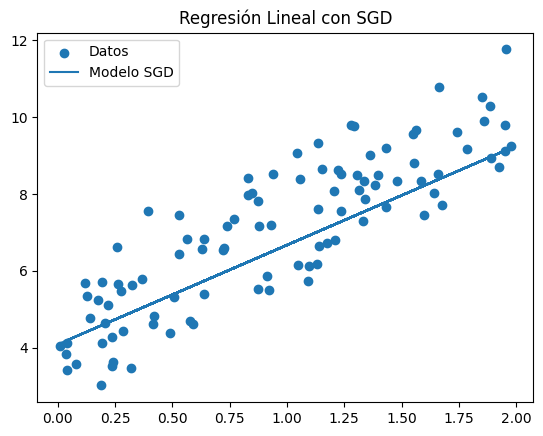

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Datos de ejemplo
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # y = 4 + 3x + ruido

# 2. Inicializar parámetros
m = np.random.randn()
b = np.random.randn()

learning_rate = 0.1
epochs = 20

# 3. SGD
for epoch in range(epochs):
    for i in range(len(X)):
        xi = X[i]
        yi = y[i]

        # Predicción
        y_pred = m * xi + b

        # Error
        error = y_pred - yi

        # Gradientes
        dm = 2 * error * xi
        db = 2 * error

        # Actualización
        m = m - learning_rate * dm
        b = b - learning_rate * db

# 4. Resultados
print(f"Pendiente (m): {m}")
print(f"Intersección (b): {b}")

# 5. Gráfica
plt.scatter(X, y, label="Datos")
plt.plot(X, m*X + b, label="Modelo SGD")
plt.legend()
plt.title("Regresión Lineal con SGD")
plt.show()

# Ejmeplo de Gradient Descent

Pendiente (m): 2.9983733974692766
Intersección (b): 4.188447837100006


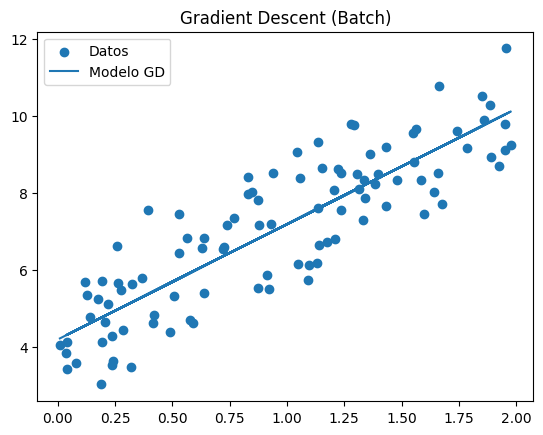

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Datos de ejemplo
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # y = 4 + 3x + ruido

# 2. Inicializar parámetros
m = 0
b = 0

learning_rate = 0.1
epochs = 100

n = len(X)

# 3. Gradient Descent (Batch)
for epoch in range(epochs):

    # Predicciones para TODOS los datos
    y_pred = m * X + b

    # Error
    error = y_pred - y

    # Gradientes (promedio)
    dm = (2/n) * np.sum(error * X)
    db = (2/n) * np.sum(error)

    # Actualización
    m = m - learning_rate * dm
    b = b - learning_rate * db

# 4. Resultados
print(f"Pendiente (m): {m}")
print(f"Intersección (b): {b}")

# 5. Gráfica
plt.scatter(X, y, label="Datos")
plt.plot(X, m*X + b, label="Modelo GD")
plt.legend()
plt.title("Gradient Descent (Batch)")
plt.show()

# Ejemplo de Stochastic Gradient Descent (SGD)

Pendiente (m): [2.83877177]
Intersección (b): [4.13384316]


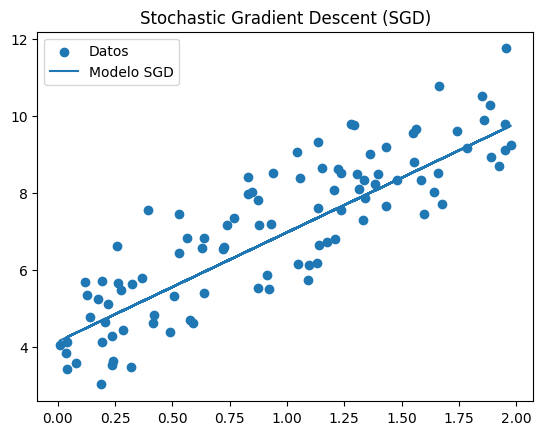

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Datos de ejemplo
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # y = 4 + 3x + ruido

# 2. Inicializar parámetros
m = 0
b = 0

learning_rate = 0.01
epochs = 20

# 3. SGD
for epoch in range(epochs):
    for i in range(len(X)):

        xi = X[i]
        yi = y[i]

        # Predicción
        y_pred = m * xi + b

        # Error
        error = y_pred - yi

        # Gradientes (solo un dato)
        dm = 2 * error * xi
        db = 2 * error

        # Actualización
        m = m - learning_rate * dm
        b = b - learning_rate * db

# 4. Resultados
print(f"Pendiente (m): {m}")
print(f"Intersección (b): {b}")

# 5. Gráfica
plt.scatter(X, y, label="Datos")
plt.plot(X, m*X + b, label="Modelo SGD")
plt.legend()
plt.title("Stochastic Gradient Descent (SGD)")
plt.show()

# Ejemplo de ADAM

Pendiente (m): 3.381938466123545
Intersección (b): 3.743735554298581


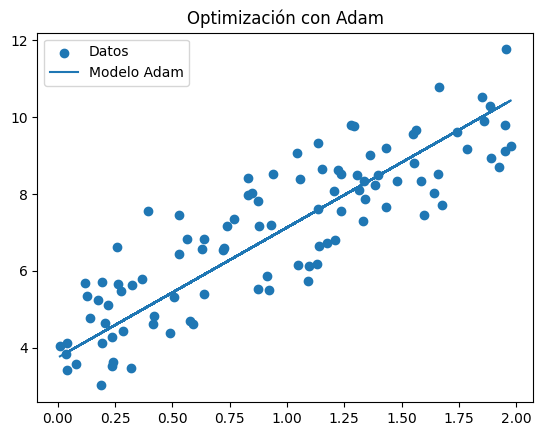

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Datos de ejemplo
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# 2. Inicializar parámetros
m = 0
b = 0

# 3. Parámetros de Adam
learning_rate = 0.1
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8

# Inicializar momentos
m_m = 0  # momento para m
v_m = 0
m_b = 0  # momento para b
v_b = 0

epochs = 100
n = len(X)

# 4. Entrenamiento con Adam
for t in range(1, epochs + 1):

    # Predicción
    y_pred = m * X + b

    # Error
    error = y_pred - y

    # Gradientes
    dm = (2/n) * np.sum(error * X)
    db = (2/n) * np.sum(error)

    # Actualizar momentos
    m_m = beta1 * m_m + (1 - beta1) * dm
    v_m = beta2 * v_m + (1 - beta2) * (dm ** 2)

    m_b = beta1 * m_b + (1 - beta1) * db
    v_b = beta2 * v_b + (1 - beta2) * (db ** 2)

    # Corrección de sesgo
    m_m_hat = m_m / (1 - beta1 ** t)
    v_m_hat = v_m / (1 - beta2 ** t)

    m_b_hat = m_b / (1 - beta1 ** t)
    v_b_hat = v_b / (1 - beta2 ** t)

    # Actualización final
    m = m - learning_rate * m_m_hat / (np.sqrt(v_m_hat) + epsilon)
    b = b - learning_rate * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

# 5. Resultados
print(f"Pendiente (m): {m}")
print(f"Intersección (b): {b}")

# 6. Gráfica
plt.scatter(X, y, label="Datos")
plt.plot(X, m*X + b, label="Modelo Adam")
plt.legend()
plt.title("Optimización con Adam")
plt.show()